# AI Customer Feedback Intelligence — EDA

This notebook covers the first stage of the project:

- Load and inspect the dataset
- Check duplicates and missing values
- Clean the data needed for analysis
- Explore the main numerical and categorical features
- Create the binary **Sentiment** target
- Save the cleaned dataset for the preprocessing notebook

> Text normalization such as lowercasing, punctuation removal, tokenization, stop-word removal, lemmatization, and TF-IDF is intentionally left for `02_preprocessing.ipynb`.

## 1. Import Libraries

We use `pandas` for data handling and `matplotlib` for visual exploration.

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Use a clean built-in plotting style
plt.style.use('ggplot')

## 2. Load the Dataset

The notebook first looks for the dataset inside `data/raw/`. If it is not there, it falls back to the current folder. The first CSV column is used as the index because it is only a saved row index.

In [27]:
# Locate the dataset
file_path = Path('data/raw/Womens Clothing E-Commerce Reviews.csv')
if not file_path.exists():
    file_path = Path('Womens Clothing E-Commerce Reviews.csv')

# Load the data and ignore the saved CSV index column
df = pd.read_csv(file_path, index_col=0)
df.head()

,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


## 3. Initial Data Inspection

Before cleaning, we check the dataset size, column types, and basic statistics to understand what we are working with.

In [28]:
# Number of rows and columns
df.shape

(23486, 10)

In [29]:
# Column names, data types, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23486 entries, 0 to 23485
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing ID              23486 non-null  int64 
 1   Age                      23486 non-null  int64 
 2   Title                    19676 non-null  object
 3   Review Text              22641 non-null  object
 4   Rating                   23486 non-null  int64 
 5   Recommended IND          23486 non-null  int64 
 6   Positive Feedback Count  23486 non-null  int64 
 7   Division Name            23472 non-null  object
 8   Department Name          23472 non-null  object
 9   Class Name               23472 non-null  object
dtypes: int64(5), object(5)
memory usage: 2.0+ MB


In [30]:
# Summary statistics for numerical columns
df.describe()

,Clothing ID,Age,Rating,Recommended IND,Positive Feedback Count
count,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000
mean,918.118709,43.198544,4.196032,0.822362,2.535936
std,203.298980,12.279544,1.110031,0.382216,5.702202
min,0.000000,18.000000,1.000000,0.000000,0.000000
25%,861.000000,34.000000,4.000000,1.000000,0.000000
50%,936.000000,41.000000,5.000000,1.000000,1.000000
75%,1078.000000,52.000000,5.000000,1.000000,3.000000
max,1205.000000,99.000000,5.000000,1.000000,122.000000


## 4. Data Quality and Cleaning

We check duplicated rows and missing values. Reviews without `Review Text` are removed because the text is the main input for the NLP model. Missing category labels are kept as `Unknown`, while missing titles are replaced with an empty string.

In [31]:
# Count duplicated rows
df.duplicated().sum()

np.int64(21)

In [32]:
# Remove duplicated rows
df.drop_duplicates(inplace=True)

# Confirm that duplicates were removed
df.duplicated().sum()

np.int64(0)

In [33]:
# Check missing values before cleaning
df.isna().sum()

,0
Clothing ID,0
Age,0
Title,3789
Review Text,825
Rating,0
Recommended IND,0
Positive Feedback Count,0
Division Name,14
Department Name,14
Class Name,14


In [34]:
# Remove rows that have no review text
df.dropna(subset=['Review Text'], inplace=True)

# Fill missing descriptive fields without deleting useful reviews
df.fillna({
    'Title': 'Empty',
    'Division Name': 'Unknown',
    'Department Name': 'Unknown',
    'Class Name': 'Unknown'
}, inplace=True)

# Verify the result
df.isna().sum()

,0
Clothing ID,0
Age,0
Title,0
Review Text,0
Rating,0
Recommended IND,0
Positive Feedback Count,0
Division Name,0
Department Name,0
Class Name,0


## 5. Exploratory Data Analysis

The following plots highlight the main patterns in ratings, customer ages, product categories, and review length. Different chart types and layouts are used to make the analysis easier to read.

### 5.1 Rating Distribution

This chart shows how customers scored the products from 1 to 5. It also helps reveal whether the dataset is skewed toward high or low ratings.

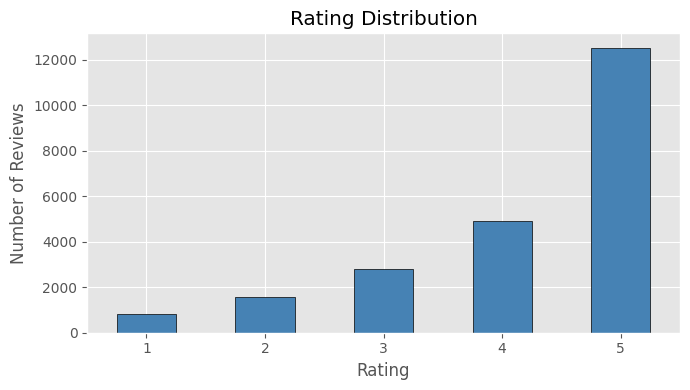

In [35]:
# Count each rating value
rating_counts = df['Rating'].value_counts().sort_index()

plt.figure(figsize=(7, 4))
rating_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.title('Rating Distribution')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 5.2 Customer Age Distribution

The age distribution gives a quick view of the customer population represented in the reviews.

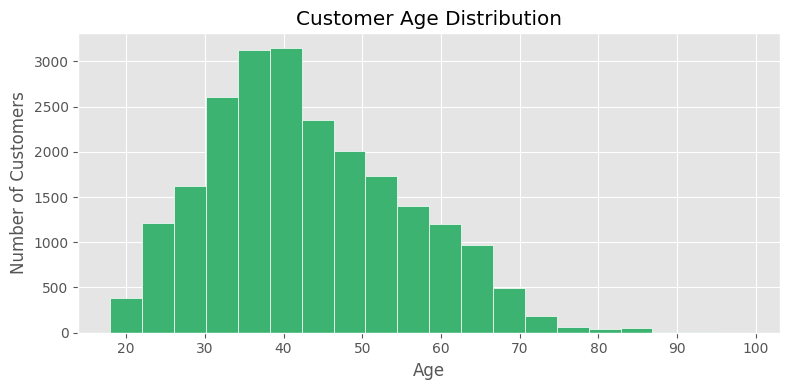

In [36]:
# Plot the distribution of customer ages
plt.figure(figsize=(8, 4))
plt.hist(df['Age'], bins=20, color='mediumseagreen', edgecolor='white')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.title('Customer Age Distribution')
plt.tight_layout()
plt.show()

### 5.3 Reviews by Product Category

These plots show where most reviews come from across departments, divisions, and clothing classes.

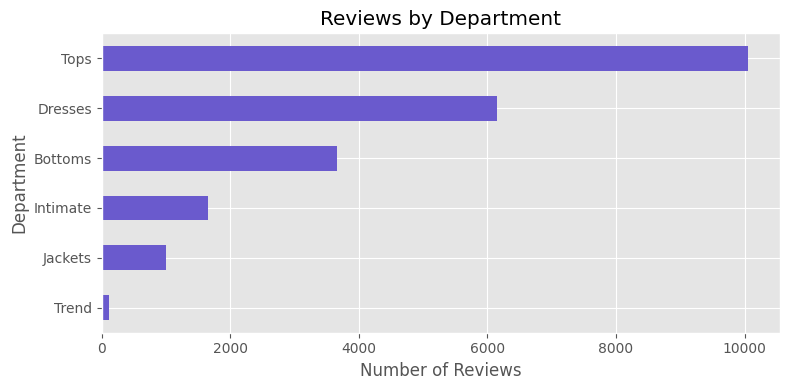

In [37]:
# Department distribution, excluding the small Unknown group
department_counts = df['Department Name'].value_counts().drop('Unknown', errors='ignore')

plt.figure(figsize=(8, 4))
department_counts.sort_values().plot(kind='barh', color='slateblue')
plt.xlabel('Number of Reviews')
plt.ylabel('Department')
plt.title('Reviews by Department')
plt.tight_layout()
plt.show()

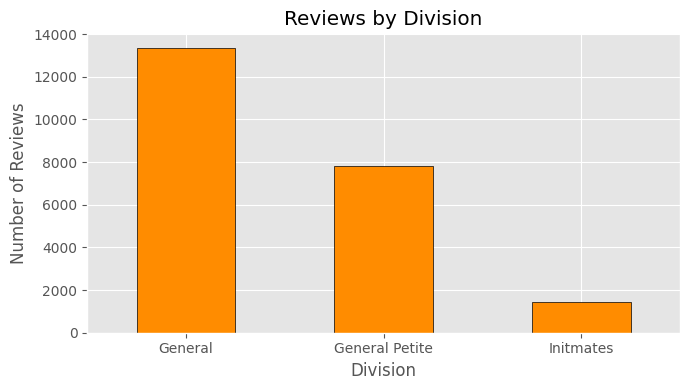

In [38]:
# Division distribution
division_counts = df['Division Name'].value_counts().drop('Unknown', errors='ignore')

plt.figure(figsize=(7, 4))
division_counts.plot(kind='bar', color='darkorange', edgecolor='black')
plt.xlabel('Division')
plt.ylabel('Number of Reviews')
plt.title('Reviews by Division')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

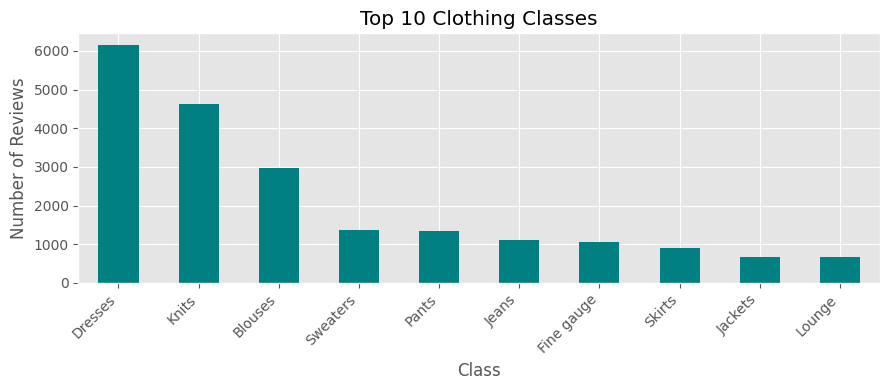

In [39]:
# Show only the 10 most common clothing classes
top_classes = df['Class Name'].value_counts().head(10)

plt.figure(figsize=(9, 4))
top_classes.plot(kind='bar', color='teal')
plt.xlabel('Class')
plt.ylabel('Number of Reviews')
plt.title('Top 10 Clothing Classes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 5.4 Review Length

Review length is useful for understanding how much text the NLP model will receive. Here it is measured as the number of characters in each review.

In [40]:
# Create a feature that stores the number of characters in each review
df['Review Length'] = df['Review Text'].str.len()

df['Review Length'].describe()

,Review Length
count,22640.000000
mean,308.550221
std,143.830238
min,9.000000
25%,186.000000
50%,301.000000
75%,458.000000
max,508.000000


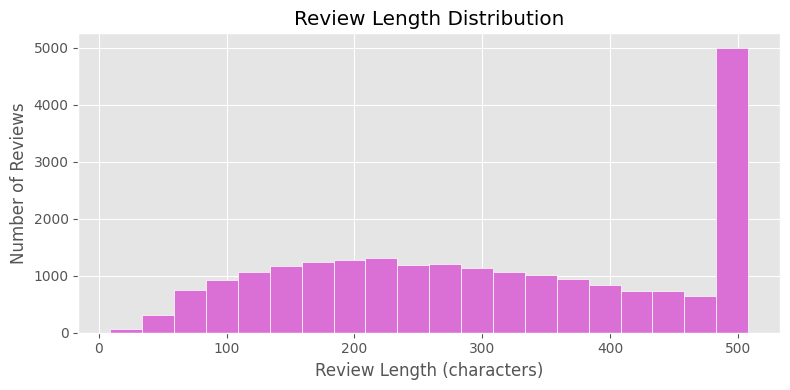

In [41]:
# Plot review length distribution
plt.figure(figsize=(8, 4))
plt.hist(df['Review Length'], bins=20, color='orchid', edgecolor='white')
plt.xlabel('Review Length (characters)')
plt.ylabel('Number of Reviews')
plt.title('Review Length Distribution')
plt.tight_layout()
plt.show()

## 6. Create the Sentiment Target

The final application is a **binary sentiment classifier**. Ratings `4` and `5` are labeled **Positive**, while ratings `1` and `2` are labeled **Negative**.

Rating `3` is removed because it is ambiguous and does not clearly represent either positive or negative sentiment.

In [42]:
# Remove neutral/ambiguous rating 3 before creating the binary target
df = df[df['Rating'] != 3].copy()

# Convert ratings into the final binary sentiment labels
df['Sentiment'] = df['Rating'].apply(
    lambda rating: 'Positive' if rating >= 4 else 'Negative'
)

df['Sentiment'].value_counts()

,count
Sentiment,
Positive,17447
Negative,2370


### 6.1 Sentiment Distribution

A pie chart makes the class balance easy to see. This is important because a strong imbalance can affect model evaluation later.

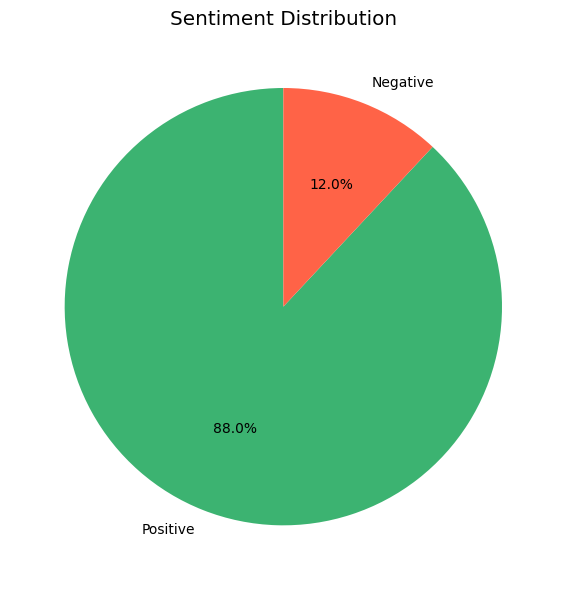

In [43]:
# Visualize the balance between positive and negative reviews
sentiment_counts = df['Sentiment'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['mediumseagreen', 'tomato']
)
plt.title('Sentiment Distribution')
plt.tight_layout()
plt.show()

### 6.2 Average Review Length by Sentiment

This comparison checks whether positive and negative customers tend to write reviews of different lengths.

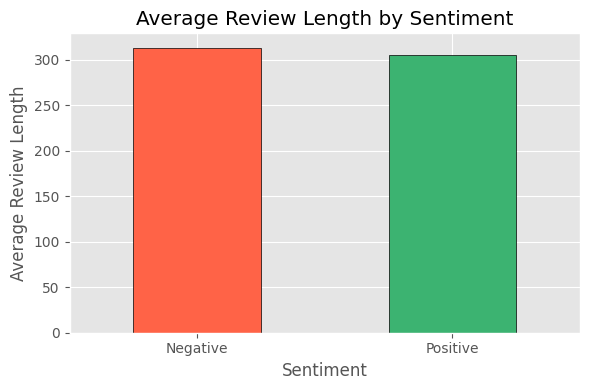

,Review Length
Sentiment,
Negative,313.451055
Positive,304.856995


In [44]:
# Compare the average review length for each sentiment
avg_length = df.groupby('Sentiment')['Review Length'].mean()

plt.figure(figsize=(6, 4))
avg_length.plot(kind='bar', color=['tomato', 'mediumseagreen'], edgecolor='black')
plt.xlabel('Sentiment')
plt.ylabel('Average Review Length')
plt.title('Average Review Length by Sentiment')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

avg_length

## 7. Recommendation Analysis

The `Recommended IND` column indicates whether the customer recommended the product. Comparing it with rating helps verify that the behavior of the dataset is consistent with the review scores.

In [45]:
# Cross-tabulation of rating and recommendation
rating_recommendation = pd.crosstab(df['Rating'], df['Recommended IND'])
rating_recommendation.columns = ['Not Recommended', 'Recommended']
rating_recommendation

,Not Recommended,Recommended
Rating,,
1,806,15
2,1455,94
4,164,4744
5,23,12516


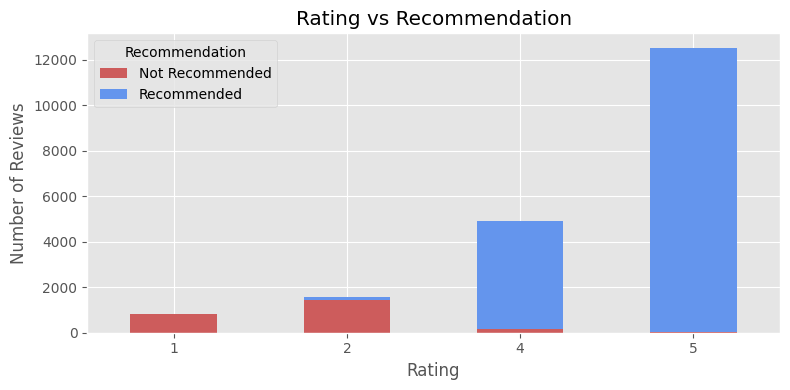

In [46]:
# Compare recommendation behavior across rating levels
rating_recommendation.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 4),
    color=['indianred', 'cornflowerblue']
)
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.title('Rating vs Recommendation')
plt.xticks(rotation=0)
plt.legend(title='Recommendation')
plt.tight_layout()
plt.show()

### 7.1 Positive Feedback by Sentiment

As an additional check, we compare the distribution of `Positive Feedback Count` between the two sentiment classes. Outliers are hidden in the plot so the main distribution is easier to see.

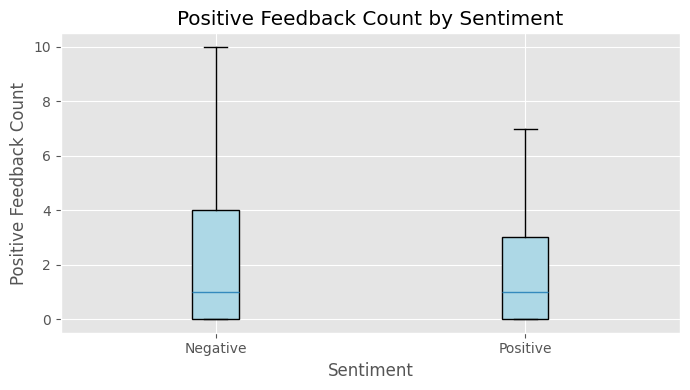

In [47]:
# Compare feedback counts between negative and positive reviews
negative_feedback = df.loc[df['Sentiment'] == 'Negative', 'Positive Feedback Count']
positive_feedback = df.loc[df['Sentiment'] == 'Positive', 'Positive Feedback Count']

plt.figure(figsize=(7, 4))
plt.boxplot(
    [negative_feedback, positive_feedback],
    tick_labels=['Negative', 'Positive'],
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor='lightblue')
)
plt.xlabel('Sentiment')
plt.ylabel('Positive Feedback Count')
plt.title('Positive Feedback Count by Sentiment')
plt.tight_layout()
plt.show()

## 8. Save the Cleaned Dataset

The cleaned dataset now contains valid review text, the derived `Review Length` feature, and the binary `Sentiment` target. It is saved for Member 2 to use in the NLP preprocessing notebook.

In [48]:
df.head()

,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,Review Length,Sentiment
0,767,33,Empty,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,53,Positive
1,1080,34,Empty,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses,303,Positive
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,124,Positive
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,192,Positive
5,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",2,0,4,General,Dresses,Dresses,488,Negative


In [49]:
from google.colab import files

df.drop(['Sentiment','Review Length'], axis=1, inplace=True)
# Save the cleaned dataset as a CSV file
df.to_csv('cleaned_reviews.csv', index=False)

# Confirm that the file was saved successfully
print('cleaned_reviews.csv saved successfully')

# Display the final shape of the cleaned dataset
print(f'Final shape: {df.shape}')

# Download the CSV file to your computer
files.download('cleaned_reviews.csv')
print(f'Final shape: {df.shape}')

cleaned_reviews.csv saved successfully
Final shape: (19817, 10)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Final shape: (19817, 10)


## 9. EDA Summary

- The dataset contains substantially more high ratings than low ratings.
- Review text is the key NLP input, so rows without review text were removed.
- Product reviews are concentrated in a few major departments and clothing classes.
- The final target is binary: **Positive** vs **Negative**.
- Rating `3` was excluded to avoid assigning an ambiguous sentiment label.
- The recommendation analysis provides an additional consistency check between customer ratings and recommendation behavior.

The dataset is now ready for the NLP preprocessing and TF-IDF stage.